In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sar004","key":"aa9e8f04567dc9b38c80e85a8f4f06d7"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vudominhgiang/uclass-stuttered-speech-clips-sep-28k-format")

print("Path to dataset files:", path)

100%|██████████| 500M/500M [00:03<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vudominhgiang/uclass-stuttered-speech-clips-sep-28k-format/versions/3


In [5]:
import os

print(os.listdir(path))

['intermediate', 'clips', 'audio_slicer.py', 'process_annotations.py', 'annotations', 'README.md', 'audio']


In [6]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "clips", "labels.csv"))
df.head()

,filepath,Block,Prolongation,SoundRep,WordRep,Interjection,NoStutteredWords
0,clips/clips/M_0030_16y4m_1_dysfluent_000.wav,1,0,1,0,0,0
1,clips/clips/M_0030_16y4m_1_dysfluent_001.wav,1,0,1,0,0,0
2,clips/clips/M_0030_16y4m_1_dysfluent_002.wav,1,0,1,0,0,0
3,clips/clips/M_0030_16y4m_1_dysfluent_003.wav,1,0,1,0,0,0
4,clips/clips/M_0030_16y4m_1_dysfluent_004.wav,0,1,0,0,1,0


In [7]:
print(df.columns)

Index(['filepath', 'Block', 'Prolongation', 'SoundRep', 'WordRep',
       'Interjection', 'NoStutteredWords'],
      dtype='object')


In [9]:
df.shape

(4712, 7)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4712 entries, 0 to 4711
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   filepath          4712 non-null   object
 1   Block             4712 non-null   int64 
 2   Prolongation      4712 non-null   int64 
 3   SoundRep          4712 non-null   int64 
 4   WordRep           4712 non-null   int64 
 5   Interjection      4712 non-null   int64 
 6   NoStutteredWords  4712 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 257.8+ KB


In [12]:
df.sample(10)

,filepath,Block,Prolongation,SoundRep,WordRep,Interjection,NoStutteredWords
257,clips/clips/M_0061_16y9m-1_dysfluent_079.wav,0,0,1,0,0,0
68,clips/clips/M_0030_16y4m_1_dysfluent_068.wav,1,1,0,0,1,0
476,clips/clips/M_0121_11y1m_1_dysfluent_011.wav,0,1,0,0,0,0
4062,clips/clips/M_1105_21y0m_1_fluent_040.wav,0,0,0,0,0,1
3631,clips/clips/M_1105_21y0m_1_dysfluent_040.wav,1,0,1,0,0,0
2671,clips/clips/M_1101_35y0m_1_dysfluent_005.wav,1,0,0,0,0,0
3523,clips/clips/M_1104_40y0m_1_fluent_029.wav,0,0,0,0,0,1
3172,clips/clips/M_1103_20y0m_1_fluent_075.wav,0,0,0,0,0,1
3591,clips/clips/M_1105_21y0m_1_dysfluent_000.wav,0,0,1,0,0,0
1947,clips/clips/M_1100_28y0m_1_dysfluent_107.wav,1,0,1,0,0,0


In [13]:
df["label"] = 1 - df["NoStutteredWords"]

df["label"].value_counts()

,count
label,
1,2490
0,2222


In [14]:
df["label"].value_counts(normalize=True)

,proportion
label,
1,0.528438
0,0.471562


In [15]:
stutter_cols = ["Block", "Prolongation", "SoundRep", "WordRep", "Interjection"]

df[stutter_cols].sum()

,0
Block,1425
Prolongation,443
SoundRep,1650
WordRep,330
Interjection,930


In [16]:
(df[stutter_cols].sum() / len(df)) * 100

,0
Block,30.241935
Prolongation,9.401528
SoundRep,35.016978
WordRep,7.003396
Interjection,19.736842


In [17]:
df_stutter = df[df["label"] == 1]

df_stutter[stutter_cols].sum()

,0
Block,1425
Prolongation,443
SoundRep,1650
WordRep,330
Interjection,930


In [18]:
df_stutter[stutter_cols].sum(axis=1).value_counts()

,count
2,1065
1,859
3,483
4,75
5,8


In [19]:
import os

file_paths = []
labels = []

for i in range(len(df)):
    full_path = os.path.join(path, df.iloc[i]["filepath"])

    if os.path.exists(full_path):
        file_paths.append(full_path)
        labels.append(df.iloc[i]["label"])

In [20]:
print(len(file_paths), len(labels))
print(file_paths[0])
print(labels[0])

4712 4712
/root/.cache/kagglehub/datasets/vudominhgiang/uclass-stuttered-speech-clips-sep-28k-format/versions/3/clips/clips/M_0030_16y4m_1_dysfluent_000.wav
1


In [22]:
import librosa
import numpy as np

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=16000)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    return mfcc.T  # (time_steps, features)

In [23]:
sample_feat = extract_features(file_paths[0])
print(sample_feat.shape)

(94, 40)


In [24]:
features = []

for file in file_paths:
    try:
        mfcc = extract_features(file)
        features.append(mfcc)
    except:
        pass

In [25]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 130  # safe average

X = pad_sequences(features, maxlen=max_len, padding='post', dtype='float32')
y = np.array(labels[:len(X)])

In [26]:
print(X.shape)
print(y.shape)

(4712, 130, 40)
(4712,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
print(X_train.shape, X_test.shape)

(3769, 130, 40) (943, 130, 40)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(130, 40)))
model.add(Dropout(0.4))

model.add(LSTM(32))
model.add(Dropout(0.4))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 130, 64)        │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 130, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,841 (155.63 KB)

 Trainable params: 39,841 (155.63 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.7461 - loss: 0.5291 - val_accuracy: 0.8367 - val_loss: 0.3901
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.8297 - loss: 0.3949 - val_accuracy: 0.8473 - val_loss: 0.3422
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8533 - loss: 0.3461 - val_accuracy: 0.8674 - val_loss: 0.3123
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - accuracy: 0.8673 - loss: 0.3127 - val_accuracy: 0.8473 - val_loss: 0.3344
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.8734 - loss: 0.3085 - val_accuracy: 0.8653 - val_loss: 0.3251
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - accuracy: 0.8883 - loss: 0.2824 - val_accuracy: 0.8834 - val_loss: 0.2836
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.8859 - loss: 0.2698 - val_accuracy: 0.8865 - val_loss: 0.2526
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.9008 - loss: 0

In [31]:
loss, acc = model.evaluate(X_test, y_test)

print("Final Accuracy:", acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8865 - loss: 0.2526
Final Accuracy: 0.8865323662757874


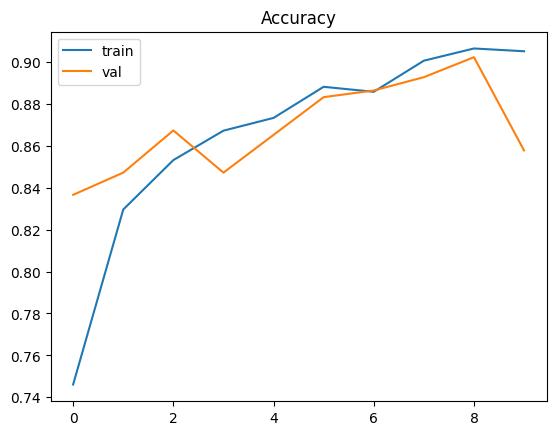

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

#trying to get type of stuttetring in the audio first usig just 3 classes due to high risk of class imbalance


In [33]:
df_stutter = df[df["label"] == 1].reset_index(drop=True)

In [34]:
print(df_stutter.shape)

(2490, 8)


In [35]:
stutter_cols = ["Block", "SoundRep", "Interjection"]

y_multi = df_stutter[stutter_cols].values

In [36]:
print(y_multi.shape)
print(y_multi[:5])

(2490, 3)
[[1 1 0]
 [1 1 0]
 [1 1 0]
 [1 1 0]
 [0 0 1]]


In [37]:
X_stutter = X[df["label"] == 1]

print(X_stutter.shape)

(2490, 130, 40)


In [38]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_stutter, y_multi, test_size=0.2, random_state=42
)

print(X_train2.shape, X_test2.shape)

(1992, 130, 40) (498, 130, 40)


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model2 = Sequential()

model2.add(LSTM(64, return_sequences=True, input_shape=(130, 40)))
model2.add(Dropout(0.4))

model2.add(LSTM(32))
model2.add(Dropout(0.4))

model2.add(Dense(16, activation='relu'))

# 🔥 OUTPUT CHANGE (IMPORTANT)
model2.add(Dense(3, activation='sigmoid'))

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 130, 64)        │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 130, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,875 (155.76 KB)

 Trainable params: 39,875 (155.76 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train2, y_train2,
    epochs=20,
    batch_size=32,
    validation_data=(X_test2, y_test2),
    callbacks=[early_stop]
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.3464 - loss: 0.6702 - val_accuracy: 0.4177 - val_loss: 0.6604
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.4880 - loss: 0.6441 - val_accuracy: 0.5502 - val_loss: 0.6520
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - accuracy: 0.5582 - loss: 0.6262 - val_accuracy: 0.6004 - val_loss: 0.6360
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.5743 - loss: 0.6172 - val_accuracy: 0.5743 - val_loss: 0.6416
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.6114 - loss: 0.6093 - val_accuracy: 0.5823 - val_loss: 0.6405
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.6416 - loss: 0.5955 - val_accuracy: 0.6004 - val_loss: 0.6191
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.6406 - loss: 0.5843 - val_accuracy: 0.5482 - val_loss: 0.6126
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.6320 - loss: 0.5791 - val_accura

In [41]:
loss2, acc2 = model2.evaluate(X_test2, y_test2)

print("Model 2 Accuracy:", acc2)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.6365 - loss: 0.5651
Model 2 Accuracy: 0.6365461945533752


In [42]:
from sklearn.metrics import classification_report

preds = model2.predict(X_test2)
preds_binary = (preds > 0.5).astype(int)

print(classification_report(y_test2, preds_binary))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step
              precision    recall  f1-score   support

           0       0.71      0.84      0.77       282
           1       0.72      0.79      0.76       321
           2       0.64      0.41      0.50       198

   micro avg       0.71      0.71      0.71       801
   macro avg       0.69      0.68      0.68       801
weighted avg       0.70      0.71      0.70       801
 samples avg       0.73      0.73      0.69       801



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


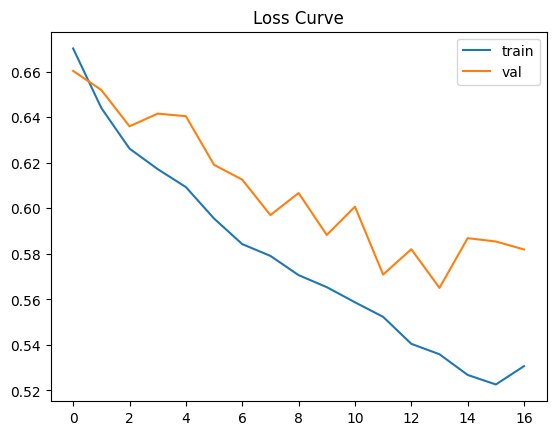

In [43]:
import matplotlib.pyplot as plt

plt.plot(history2.history['loss'], label='train')
plt.plot(history2.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()